In [ ]:
!pip install -q bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 11.3 MB/s eta 0:00:00


In [ ]:
import torch
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor, BitsAndBytesConfig
from PIL import Image
import requests
from io import BytesIO

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)

model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()

url = "http://images.cocodataset.org/val2017/000000039769.jpg"
response = requests.get(url)
image = Image.open(BytesIO(response.content)).convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": "Describe the cats in this image."}
        ]
    }
]

prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)

inputs = processor(
    text=[prompt],
    images=[image],
    padding=True,
    return_tensors="pt"
).to(model.device)

print("--- Inputs generated by Processor ---")
for key, value in inputs.items():
    if isinstance(value, torch.Tensor):
        print(f"{key}: {value.shape}")
    else:
        print(f"{key}: {type(value)}")

print("\n--- Image Grid THW (Time, Height, Width) ---")
if "image_grid_thw" in inputs:
    thw = inputs["image_grid_thw"][0]
    print(f"Time: {thw[0]}, Height: {thw[1]}, Width: {thw[2]}")
    print(f"Total Vision Tokens (H x W): {thw[1] * thw[2]}")

print("\n--- Token IDs & Decoding ---")
input_ids = inputs["input_ids"][0]
tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)

vision_start_token = "<|vision_start|>"
vision_end_token = "<|vision_end|>"
image_pad_token = "<|image_pad|>"

try:
    start_idx = tokens.index(vision_start_token)
    end_idx = tokens.index(vision_end_token)
    pad_count = tokens.count(image_pad_token)
    print(f"Vision Start Index: {start_idx}")
    print(f"Vision End Index: {end_idx}")
    print(f"Number of <|image_pad|> tokens: {pad_count}")
except ValueError:
    print("Vision structural tokens not found in standard way.")

print("\n--- Forward Pass ---")
with torch.no_grad():
    outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

print("\n--- Attentions and Hidden States ---")
if outputs.attentions is not None:
    num_layers = len(outputs.attentions)
    attn_shape = outputs.attentions[0].shape
    print(f"Number of Attention Layers: {num_layers}")
    print(f"Shape of Attention Matrix (Layer 0): {attn_shape} -> (Batch, Heads, Seq_Len, Seq_Len)")

if outputs.hidden_states is not None:
    num_hidden = len(outputs.hidden_states)
    hidden_shape = outputs.hidden_states[-1].shape
    print(f"Number of Hidden States: {num_hidden}")
    print(f"Shape of Last Hidden State: {hidden_shape} -> (Batch, Seq_Len, Hidden_Dim)")

print("\n--- Finding Target Text Indices ---")
text_start_idx = end_idx + 1 if 'end_idx' in locals() else 0
print(f"Text tokens start at index: {text_start_idx}")
print("Tokens from Vision End to sequence end:")
for i in range(text_start_idx, len(tokens)):
    print(f"[{i}]: {tokens[i]}")

preprocessor_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/1.05k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.37k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/5.70k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)


generation_config.json:   0%|          | 0.00/216 [00:00<?, ?B/s]

--- Inputs generated by Processor ---
input_ids: torch.Size([1, 419])
attention_mask: torch.Size([1, 419])
mm_token_type_ids: torch.Size([1, 419])
pixel_values: torch.Size([1564, 1176])
image_grid_thw: torch.Size([1, 3])

--- Image Grid THW (Time, Height, Width) ---
Time: 1, Height: 34, Width: 46
Total Vision Tokens (H x W): 1564

--- Token IDs & Decoding ---
Vision Start Index: 14
Vision End Index: 406
Number of <|image_pad|> tokens: 391

--- Forward Pass ---

--- Attentions and Hidden States ---
Number of Attention Layers: 36
Shape of Attention Matrix (Layer 0): torch.Size([1, 16, 419, 419]) -> (Batch, Heads, Seq_Len, Seq_Len)
Number of Hidden States: 37
Shape of Last Hidden State: torch.Size([1, 419, 2048]) -> (Batch, Seq_Len, Hidden_Dim)

--- Finding Target Text Indices ---
Text tokens start at index: 407
Tokens from Vision End to sequence end:
[407]: Describe
[408]: Ġthe
[409]: Ġcats
[410]: Ġin
[411]: Ġthis
[412]: Ġimage
[413]: .
[414]: <|im_end|>
[415]: Ċ
[416]: <|im_start|>
[417

In [ ]:
import torch
import numpy as np
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from datasets import load_dataset
import requests
from io import BytesIO
from PIL import Image
import warnings
import logging

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

print("Loading processor and model...")
processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()

print("Loading dataset...")
dataset = load_dataset("phiyodr/coco2017", split="validation", streaming=True)
iterator = iter(dataset)

print("\nDebug Trace for one sample")

found_valid_sample = False
while not found_valid_sample:
    data = next(iterator)

    if 'image' in data and data['image'] is not None:
        image = data['image'].convert("RGB")
    elif 'coco_url' in data:
        try:
            response = requests.get(data['coco_url'], timeout=10)
            image = Image.open(BytesIO(response.content)).convert("RGB")
        except:
            continue
    else:
        continue

    caption = data['captions'][0] if isinstance(data.get('captions'), list) else data.get('text', "")
    if not caption:
        continue

    found_valid_sample = True

print(f"Caption: {caption}")
target_noun = caption.split()[1] if len(caption.split()) > 1 else caption.split()[0]
print(f"Mock Target Noun for testing: {target_noun}")

image_copy = image.copy()
image_copy.thumbnail((512, 512))

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": caption}
        ]
    }
]

prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
inputs = processor(text=[prompt], images=[image_copy], return_tensors="pt").to(model.device)
input_ids = inputs["input_ids"][0].tolist()

print("\n[CHECK 1] Processor Outputs:")
for k, v in inputs.items():
    if isinstance(v, torch.Tensor):
        print(f" - {k}: {v.shape}")

if "image_grid_thw" not in inputs:
    print("\nFAIL: 'image_grid_thw' missing from inputs!")
    exit()

thw = inputs["image_grid_thw"][0]
print(f"\n[CHECK 2] THW Values: Time={thw[0].item()}, Height={thw[1].item()}, Width={thw[2].item()}")

orig_grid_h, orig_grid_w = thw[1].item(), thw[2].item()
grid_h, grid_w = orig_grid_h // 2, orig_grid_w // 2

print(f"Calculated orig_grid: {orig_grid_h}x{orig_grid_w} = {orig_grid_h * orig_grid_w}")
print(f"Calculated grid (// 2): {grid_h}x{grid_w} = {grid_h * grid_w}")

tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
print(f"\n[CHECK 3] Total sequence length: {len(tokens)}")

if "<|vision_start|>" not in tokens or "<|vision_end|>" not in tokens:
    print("\nFAIL: <|vision_start|> or <|vision_end|> not found in tokens array!")
    print("Tokens subset (first 50):", tokens[:50])
    exit()

img_start = tokens.index("<|vision_start|>") + 1
img_end = tokens.index("<|vision_end|>")
vision_token_count = img_end - img_start

print(f"\n[CHECK 4] Vision Tokens:")
print(f" - img_start index: {img_start}")
print(f" - img_end index: {img_end}")
print(f" - Vision token count (img_end - img_start): {vision_token_count}")

if vision_token_count != (grid_h * grid_w):
    print(f"\nFAIL: Condition (img_end - img_start) == (grid_h * grid_w) failed!")
    print(f" - Vision token count: {vision_token_count}")
    print(f" - grid_h * grid_w: {grid_h * grid_w}")
    print(f" - orig_grid_h * orig_grid_w: {orig_grid_h * orig_grid_w}")
    print("-> This is why it was skipping all images!")
else:
    print("\nSUCCESS: Grid dimensions match vision token count!")

text_indices = list(range(img_end + 1, len(input_ids)))
print(f"\n[CHECK 5] Text indices start at: {text_indices[0]}, length: {len(text_indices)}")

target_indices = []
for i in text_indices:
    t = tokens[i]
    clean_token = t.lower().replace("ġ", "").replace("ĉ", "").replace(" ", "").replace("_", "")
    if any(word in clean_token or clean_token in word for word in target_noun.lower().split()):
        target_indices.append(i)

if not target_indices:
    print(f"\nFAIL: Target noun '{target_noun}' not found in decoded text tokens!")
    print("Available text tokens:")
    for idx in text_indices:
        print(f"[{idx}]: {tokens[idx]}")
else:
    print(f"\nSUCCESS: Target '{target_noun}' found at indices: {target_indices}")
    print("Tokens mapped:", [tokens[i] for i in target_indices])

print("\nDebug trace complete. Review the 'FAIL' message above to see what broke the loop.")

Loading processor and model...


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]

Loading dataset...

--- STARTING DEBUG TRACE FOR 1 SAMPLE ---
Caption: A man is in a kitchen making pizzas.
Mock Target Noun for testing: man

[CHECK 1] Processor Outputs:
 - input_ids: torch.Size([1, 246])
 - attention_mask: torch.Size([1, 246])
 - mm_token_type_ids: torch.Size([1, 246])
 - pixel_values: torch.Size([864, 1176])
 - image_grid_thw: torch.Size([1, 3])

[CHECK 2] THW Values: Time=1, Height=24, Width=36
Calculated orig_grid: 24x36 = 864
Calculated grid (// 2): 12x18 = 216

[CHECK 3] Total sequence length: 246

[CHECK 4] Vision Tokens:
 - img_start index: 15
 - img_end index: 231
 - Vision token count (img_end - img_start): 216

SUCCESS: Grid dimensions match vision token count!

[CHECK 5] Text indices start at: 232, length: 14

SUCCESS: Target 'man' found at indices: [232, 233, 236]
Tokens mapped: ['A', 'Ġman', 'Ġa']

Debug trace complete. Review the 'FAIL' message above to see what broke the loop.


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/824 [00:00<?, ?it/s]


Starting Large-Scale Qwen2.5-VL Pointing Game on MS COCO (1000 objects)...



Evaluating:  10%|█         | 100/1000 [06:52<1:08:54,  4.59s/obj]

...


--- Pointing Game Accuracy (800/1000) ---
Raw Attention             | 43.4%
Attention Rollout         | 6.4%
ViT-Grad-CAM              | 30.6%
Attn x Grad (Chefer)      | 41.2%
Deep-Spec (Ours)          | 57.4%
--------------------------------------------------


Evaluating:  90%|█████████ | 900/1000 [1:02:09<07:41,  4.61s/obj]


--- Pointing Game Accuracy (900/1000) ---
Raw Attention             | 43.3%
Attention Rollout         | 5.9%
ViT-Grad-CAM              | 30.2%
Attn x Grad (Chefer)      | 40.3%
Deep-Spec (Ours)          | 57.4%
--------------------------------------------------


Evaluating: 100%|██████████| 1000/1000 [1:09:02<00:00,  4.14s/obj]



--- Pointing Game Accuracy (1000/1000) ---
Raw Attention             | 43.9%
Attention Rollout         | 5.8%
ViT-Grad-CAM              | 30.3%
Attn x Grad (Chefer)      | 40.8%
Deep-Spec (Ours)          | 57.7%
--------------------------------------------------

     FINAL MS COCO POINTING GAME ACCURACY (Qwen2.5-VL)      
Method                    | Hit Acc (%)  | Variance   | Std Dev   
------------------------------------------------------------
   Raw Attention          |      43.90 |     0.2465 |     0.4965
   Attention Rollout      |       5.80 |     0.0547 |     0.2339
   ViT-Grad-CAM           |      30.30 |     0.2114 |     0.4598
   Attn x Grad (Chefer)   |      40.80 |     0.2418 |     0.4917
>> Deep-Spec (Ours)       |      57.70 |     0.2443 |     0.4943

Total Evaluated Samples: 1000
------------------------------------------------------------
 EXCLUSIVE HITS (Only this method got it right) 
------------------------------------------------------------
Raw Attention      

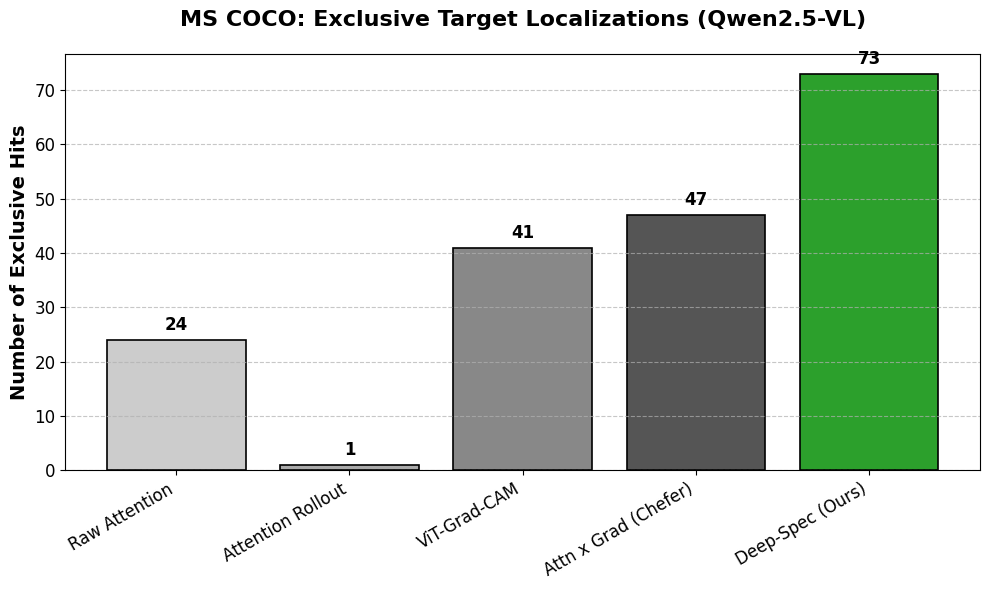

In [ ]:
import torch
import numpy as np
from scipy.linalg import eigh
from transformers import AutoProcessor, Qwen2_5_VLForConditionalGeneration, BitsAndBytesConfig
from datasets import load_dataset
from tqdm import tqdm
import warnings
import logging
import os
import json
import requests
import zipfile
from io import BytesIO
from PIL import Image
import matplotlib.pyplot as plt
import gc

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")

NUM_EVALS = 1000
model_id = "Qwen/Qwen2.5-VL-3B-Instruct"

quantization_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type="nf4"
)

processor = AutoProcessor.from_pretrained(model_id)
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    model_id,
    quantization_config=quantization_config,
    device_map={"": 0},
    attn_implementation="eager",
    low_cpu_mem_usage=True
)
model.eval()

ANNOTATION_FILE = "instances_val2017.json"
if not os.path.exists(ANNOTATION_FILE):
    r = requests.get("http://images.cocodataset.org/annotations/annotations_trainval2017.zip", stream=True)
    with open("annotations.zip", 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    with zipfile.ZipFile("annotations.zip", 'r') as zip_ref:
        zip_ref.extract("annotations/instances_val2017.json", ".")
    os.rename("annotations/instances_val2017.json", ANNOTATION_FILE)
    if os.path.exists("annotations.zip"): os.remove("annotations.zip")
    import shutil
    if os.path.exists("annotations"): shutil.rmtree("annotations")

with open(ANNOTATION_FILE, 'r') as f:
    coco_data = json.load(f)

categories = {cat['id']: cat['name'] for cat in coco_data['categories']}
image_to_objects = {}
for ann in coco_data['annotations']:
    img_id = ann['image_id']
    if img_id not in image_to_objects:
        image_to_objects[img_id] = []
    image_to_objects[img_id].append({
        'category_name': categories[ann['category_id']],
        'bbox': ann['bbox']
    })

dataset = load_dataset("phiyodr/coco2017", split="validation", streaming=True)

methods = ["Raw Attention", "Attention Rollout", "ViT-Grad-CAM", "Attn x Grad (Chefer)", "Deep-Spec (Ours)"]
hits = {m: 0 for m in methods}
results_per_sample = {m: [] for m in methods}
total_evaluated = 0

def extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices, grid_h, grid_w, orig_grid_h, orig_grid_w):
    heatmaps = {}

    with torch.no_grad():
        outputs_nograd = model(**inputs, output_attentions=True)
        all_layers_attn = torch.stack(outputs_nograd.attentions).detach().cpu().squeeze(1)
        avg_attn = all_layers_attn.mean(dim=(0, 1))

        hm_raw = avg_attn[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
        hm_raw = hm_raw / (hm_raw.max() + 1e-10)
        heatmaps["Raw Attention"] = hm_raw.to(torch.float32).numpy()

        S_len = avg_attn.shape[0]
        rollout = torch.eye(S_len, dtype=torch.float32)
        for layer_attn in all_layers_attn:
            avg_heads = layer_attn.mean(dim=0).to(torch.float32)
            avg_heads = 0.5 * avg_heads + 0.5 * torch.eye(S_len, dtype=torch.float32)
            rollout = rollout @ avg_heads
        hm_roll = rollout[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
        hm_roll = hm_roll / (hm_roll.max() + 1e-10)
        heatmaps["Attention Rollout"] = hm_roll.numpy()

        W_c = avg_attn[text_indices][:, img_start:img_end]
        W_c = W_c / (W_c.max() + 1e-10)
        W_c_np = W_c.to(torch.float32).numpy()

        T_ds, I_ds = W_c_np.shape
        N = T_ds + I_ds
        W = np.zeros((N, N))
        W[:T_ds, T_ds:] = W_c_np
        W[T_ds:, :T_ds] = W_c_np.T
        W = W + 1e-5

        D = np.sum(W, axis=1)
        D[D == 0] = 1e-5
        D_inv_sqrt = np.diag(1.0 / np.sqrt(D))
        L_sym = np.eye(N) - D_inv_sqrt @ W @ D_inv_sqrt
        _, eigvecs = eigh(L_sym)

        K_components = min(5, T_ds - 1) if T_ds > 5 else 1
        if K_components > 0:
            V_text = eigvecs[:T_ds, 1:K_components+1]
            V_img = eigvecs[T_ds:, 1:K_components+1]
            denoised_affinity = V_text @ V_img.T
            tgt_rel_mapped = [text_indices.index(idx) for idx in tgt_rel]
            target_affinity = np.abs(denoised_affinity[tgt_rel_mapped, :])
            hm_ds = target_affinity.max(axis=0).reshape(grid_h, grid_w)
            hm_ds = (hm_ds - hm_ds.min()) / (hm_ds.max() - hm_ds.min() + 1e-10)
            heatmaps["Deep-Spec (Ours)"] = hm_ds
        else:
            heatmaps["Deep-Spec (Ours)"] = np.zeros((grid_h, grid_w))

        del outputs_nograd
        del all_layers_attn
        gc.collect()
        torch.cuda.empty_cache()

    activations, gradients = None, None

    def fwd_hook(m, inp, out):
        nonlocal activations
        activations = out[0].detach() if isinstance(out, tuple) else out.detach()

    def bwd_hook(m, gin, gout):
        nonlocal gradients
        gradients = gout[0].detach() if isinstance(gout, tuple) else gout.detach()

    target_layer = None
    for name, m in model.named_modules():
        if ("visual.blocks" in name or "vision_tower" in name) and name.split('.')[-1].isdigit():
            target_layer = m

    h1, h2 = None, None
    if target_layer is not None:
        h1 = target_layer.register_forward_hook(fwd_hook)
        h2 = target_layer.register_full_backward_hook(bwd_hook)

    if "pixel_values" in inputs:
        inputs["pixel_values"].requires_grad_(True)
    if "image_features" in inputs and inputs["image_features"].is_floating_point():
        inputs["image_features"].requires_grad_(True)

    model.zero_grad()

    try:
        outputs = model(**inputs, output_attentions=True, output_hidden_states=True)

        if hasattr(outputs, 'logits'):
            del outputs.logits

        for a in outputs.attentions:
            a.retain_grad()

        loss = outputs.hidden_states[-1][0, tgt_rel].sum()
        loss.backward()

        if gradients is not None and activations is not None:
            acts = activations[0] if activations.dim() == 3 else activations
            grads = gradients[0] if gradients.dim() == 3 else gradients

            if acts.shape[0] == orig_grid_h * orig_grid_w:
                weights = grads.mean(dim=0)
                cam = (weights * acts).sum(dim=-1)
                cam = torch.relu(cam)
                cam = cam.reshape(1, 1, orig_grid_h, orig_grid_w)
                cam = torch.nn.functional.interpolate(cam.float(), size=(grid_h, grid_w), mode='bilinear').squeeze()
                if cam.max() > 0: cam = cam / (cam.max() + 1e-10)
                heatmaps["ViT-Grad-CAM"] = cam.detach().cpu().to(torch.float32).numpy()
            else:
                heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))
        else:
            heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))

        heatmap_chefer = torch.zeros((S_len, S_len), device="cpu", dtype=torch.float32)
        count = 0
        for a in outputs.attentions:
            if a.grad is not None:
                grad = a.grad.detach().cpu().to(torch.float32).squeeze(0)
                attn = a.detach().cpu().to(torch.float32).squeeze(0)
                heatmap_chefer += (attn * grad).mean(dim=0)
                count += 1

        if count > 0:
            heatmap_chefer = heatmap_chefer / count
            heatmap_chefer = torch.clamp(heatmap_chefer, min=0)
            hm_chefer = heatmap_chefer[tgt_rel][:, img_start:img_end].max(dim=0).values.reshape(grid_h, grid_w)
            if hm_chefer.max() > 0: hm_chefer = hm_chefer / (hm_chefer.max() + 1e-10)
            heatmaps["Attn x Grad (Chefer)"] = hm_chefer.numpy()
        else:
            heatmaps["Attn x Grad (Chefer)"] = np.zeros((grid_h, grid_w))

    except Exception:
        heatmaps["ViT-Grad-CAM"] = np.zeros((grid_h, grid_w))
        heatmaps["Attn x Grad (Chefer)"] = np.zeros((grid_h, grid_w))
    finally:
        if h1 is not None: h1.remove()
        if h2 is not None: h2.remove()
        if 'outputs' in locals(): del outputs
        gc.collect()
        torch.cuda.empty_cache()

    return heatmaps

print(f"\nStarting Large-Scale Qwen2.5-VL Pointing Game on MS COCO ({NUM_EVALS} objects)...\n")
iterator = iter(dataset)

with tqdm(total=NUM_EVALS, desc="Evaluating", unit="obj") as pbar:
    while total_evaluated < NUM_EVALS:
        try:
            data = next(iterator)
            image_id = data.get('image_id')

            if image_id not in image_to_objects: continue
            objects = image_to_objects[image_id]

            if 'image' in data and data['image'] is not None:
                image = data['image'].convert("RGB")
            elif 'coco_url' in data:
                try:
                    response = requests.get(data['coco_url'], timeout=10)
                    image = Image.open(BytesIO(response.content)).convert("RGB")
                except: continue
            else: continue

            orig_W, orig_H = image.size
            caption = data['captions'][0] if isinstance(data.get('captions'), list) else data.get('text', "")
            if not caption: continue

            target_noun = None
            for obj in objects:
                if obj['category_name'].lower() in caption.lower():
                    target_noun = obj['category_name']
                    break

            if not target_noun: continue
            all_target_bboxes = [obj['bbox'] for obj in objects if obj['category_name'] == target_noun]

            image_copy = image.copy()
            image_copy.thumbnail((512, 512))

            messages = [
                {
                    "role": "user",
                    "content": [
                        {"type": "image"},
                        {"type": "text", "text": caption}
                    ]
                }
            ]

            prompt = processor.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
            inputs = processor(text=[prompt], images=[image_copy], return_tensors="pt").to(model.device)
            input_ids = inputs["input_ids"][0].tolist()

            if "image_grid_thw" not in inputs: continue
            thw = inputs["image_grid_thw"][0]
            orig_grid_h, orig_grid_w = thw[1].item(), thw[2].item()
            grid_h, grid_w = orig_grid_h // 2, orig_grid_w // 2

            tokens = processor.tokenizer.convert_ids_to_tokens(input_ids)
            if "<|vision_start|>" not in tokens or "<|vision_end|>" not in tokens: continue

            img_start = tokens.index("<|vision_start|>") + 1
            img_end = tokens.index("<|vision_end|>")

            if (img_end - img_start) != (grid_h * grid_w): continue

            text_indices = list(range(img_end + 1, len(input_ids)))
            if not text_indices: continue

            target_indices = []
            target_words = target_noun.lower().split()
            for i in text_indices:
                t = tokens[i].lower().replace("ġ", "").replace("ĉ", "").replace(" ", "").replace("_", "")
                if t in target_words:
                    target_indices.append(i)

            if not target_indices: continue
            tgt_rel = target_indices

            heatmaps = extract_all_heatmaps(inputs, tgt_rel, img_start, img_end, text_indices, grid_h, grid_w, orig_grid_h, orig_grid_w)
            if heatmaps is None: continue

            for m_name in methods:
                hm = heatmaps[m_name]
                if hm.max() == 0:
                    results_per_sample[m_name].append(0)
                    continue

                max_idx = np.argmax(hm)
                max_y_patch, max_x_patch = np.unravel_index(max_idx, hm.shape)
                rel_x = (max_x_patch + 0.5) / grid_w
                rel_y = (max_y_patch + 0.5) / grid_h
                pixel_x = rel_x * orig_W
                pixel_y = rel_y * orig_H

                hit = False
                for bbox in all_target_bboxes:
                    x_min, y_min, bbox_w, bbox_h = bbox
                    x_max, y_max = x_min + bbox_w, y_min + bbox_h
                    if (x_min <= pixel_x <= x_max) and (y_min <= pixel_y <= y_max):
                        hit = True
                        break

                if hit: hits[m_name] += 1
                results_per_sample[m_name].append(1 if hit else 0)

            total_evaluated += 1
            pbar.update(1)

            if total_evaluated % 100 == 0:
                pbar.write(f"\n--- Pointing Game Accuracy ({total_evaluated}/{NUM_EVALS}) ---")
                for m_name in methods:
                    acc = (hits[m_name] / total_evaluated) * 100
                    pbar.write(f"{m_name:<25} | {acc:.1f}%")
                pbar.write("-" * 50)

        except StopIteration:
            break

print("\n" + "=" * 60)
print(" FINAL MS COCO POINTING GAME ACCURACY (Qwen2.5-VL) ".center(60))
print("=" * 60)
print(f"{'Method':<25} | {'Hit Acc (%)':<12} | {'Variance':<10} | {'Std Dev':<10}")
print("-" * 60)
for m_name in methods:
    arr = np.array(results_per_sample[m_name])
    acc = arr.mean() * 100 if len(arr) > 0 else 0
    var = arr.var(ddof=1) if len(arr) > 1 else 0.0
    std = arr.std(ddof=1) if len(arr) > 1 else 0.0
    prefix = ">> " if "Deep-Spec" in m_name else "   "
    print(f"{prefix}{m_name:<22} | {acc:>10.2f} | {var:>10.4f} | {std:>10.4f}")
print("=" * 60)

num_samples = len(results_per_sample["Deep-Spec (Ours)"])
exclusive_hits_count = {m: 0 for m in methods}
for i in range(num_samples):
    hits_for_sample = [m for m in methods if results_per_sample[m][i] == 1]
    if len(hits_for_sample) == 1:
        exclusive_m = hits_for_sample[0]
        exclusive_hits_count[exclusive_m] += 1

print(f"\nTotal Evaluated Samples: {num_samples}")
print("-" * 60)
print(" EXCLUSIVE HITS (Only this method got it right) ")
print("-" * 60)
for m in methods:
    print(f"{m:<25} | {exclusive_hits_count[m]}")
print("-" * 60)

plt.figure(figsize=(10, 6))
colors = ['#cccccc', '#aaaaaa', '#888888', '#555555', '#2ca02c']
bars = plt.bar(methods, [exclusive_hits_count[m] for m in methods], color=colors, edgecolor='black', linewidth=1.2)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 1, int(yval), ha='center', va='bottom', fontweight='bold', fontsize=12)

plt.title("MS COCO: Exclusive Target Localizations (Qwen2.5-VL)", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Number of Exclusive Hits", fontsize=14, fontweight='bold')
plt.xticks(rotation=30, ha='right', fontsize=12)
plt.yticks(fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

pdf_filename = "Deep_Spec_Exclusive_Hits_Qwen2_5_VL_mscoco.pdf"
plt.savefig(pdf_filename, format="pdf", dpi=300, bbox_inches='tight')
plt.show()